In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from iminuit import Minuit
from iminuit import cost

def calc(x):
    print(x-180)
    print(x+180)

In [3]:
freq = np.array([500, 750, 1000, 1500, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10_000, 11_000, 12_000, 13_000, 14_000, 15_000, 16_000, 17_000, 18_000, 19_000, 20_000, 22_000, 24_000, 26_000, 30_000, 40_000]) #Hz
Vmax = np.array([18*1e-3, 34*1e-3, 67*1e-3, 99*1e-3, 102*1e-3, 108e-3, 394e-3, 236e-3, 433e-3, 913e-3, 1.566, 2.221, 2.776, 2.955, 2.742, 2.327, 1.871, 1.480, 1.161, 935e-3, 764e-3, 632e-3, 515e-3, 370e-3, 246e-3, 160e-3, 48e-3, -041e-3]) #V
Vmin = np.array([-26*1e-3, -50*1e-3, -64*1e-3, -95*1e-3, -121*1e-3, -307*1e-3, -154*1e-3, -537e-3, -620e-3, -459e-3, -135e-3, 211e-3, 553e-3, 672e-3, 521e-3, 285e-3, 036e-3, -154e-3, -292e-3, -376e-3, -420e-3, -473e-3, -485e-3, -502e-3, -520e-3, -523e-3, -510e-3, -435e-3]) #V
phase = np.array([-90, -94, -106, -126, -138, 140, 112, 116, 100, 89, 70, 49, 23, -2, -10, -25, -41, -49, -55, -62, -68, -70, -84, -89, -93, -101, -113, -169]) #degrees
calc(phase[-1])
print('Measurements:', len(freq), len(Vmax), len(Vmin), len(phase))

-349
11
Measurements: 28 28 28 28


In [4]:
freqdiff = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000]) #Hz
ampRMS = np.array([830.2, 828, 829.8, 830.1, 829.8, 829.9, 831.4, 832.2, 831.5, 832.2, 827.2, 817.8, 805, 792.7, 772.1, 752.6, 732.5, 710.9, 688.8, 494, 366.7, 287.5, 234.8, 198, 171.2, 150.2, 134.1, 120.9, 63, 44 ])    ## mV


amp = ampRMS*np.sqrt(2)


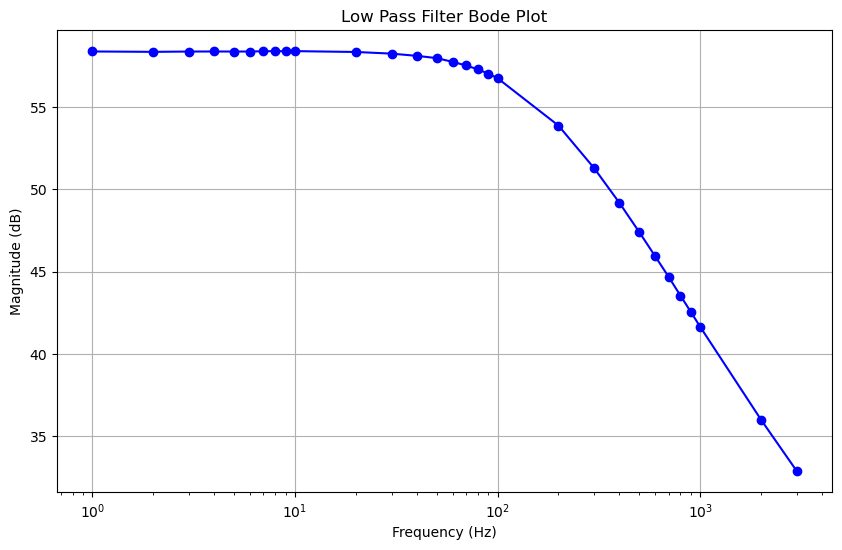

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Low Pass Filter Bode Plot')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.plot(freqdiff, 20*np.log10(ampRMS), 'o-', color='blue')
ax.set_xscale('log')
ax.grid();

In [6]:
offset = (Vmax + Vmin) / 2
ampl = (Vmax-Vmin)/2
print(ampl)

[0.022  0.042  0.0655 0.097  0.1115 0.2075 0.274  0.3865 0.5265 0.686
 0.8505 1.005  1.1115 1.1415 1.1105 1.021  0.9175 0.817  0.7265 0.6555
 0.592  0.5525 0.5    0.436  0.383  0.3415 0.279  0.197 ]


In [7]:
print(phase)
print(np.deg2rad(phase))

[ -90  -94 -106 -126 -138  140  112  116  100   89   70   49   23   -2
  -10  -25  -41  -49  -55  -62  -68  -70  -84  -89  -93 -101 -113 -169]
[-1.57079633 -1.6406095  -1.85004901 -2.19911486 -2.40855437  2.44346095
  1.95476876  2.02458193  1.74532925  1.55334303  1.22173048  0.85521133
  0.40142573 -0.03490659 -0.17453293 -0.43633231 -0.71558499 -0.85521133
 -0.95993109 -1.08210414 -1.18682389 -1.22173048 -1.46607657 -1.55334303
 -1.6231562  -1.76278254 -1.97222205 -2.94960644]


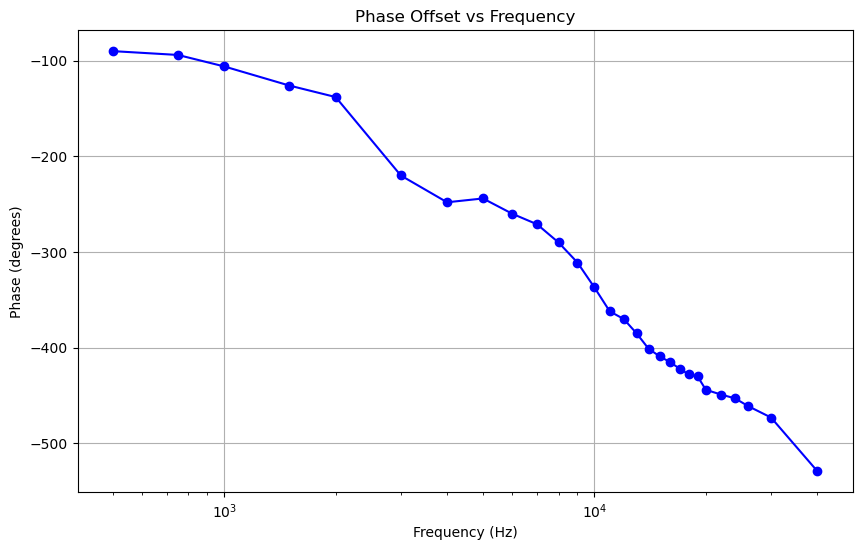

In [8]:
# phase_rad = np.deg2rad(phase)
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Phase Offset vs Frequency')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Phase (degrees)')
ax.plot(freq, np.unwrap(phase, period=360), 'o-', color='blue')
ax.set_xscale('log')
ax.grid()

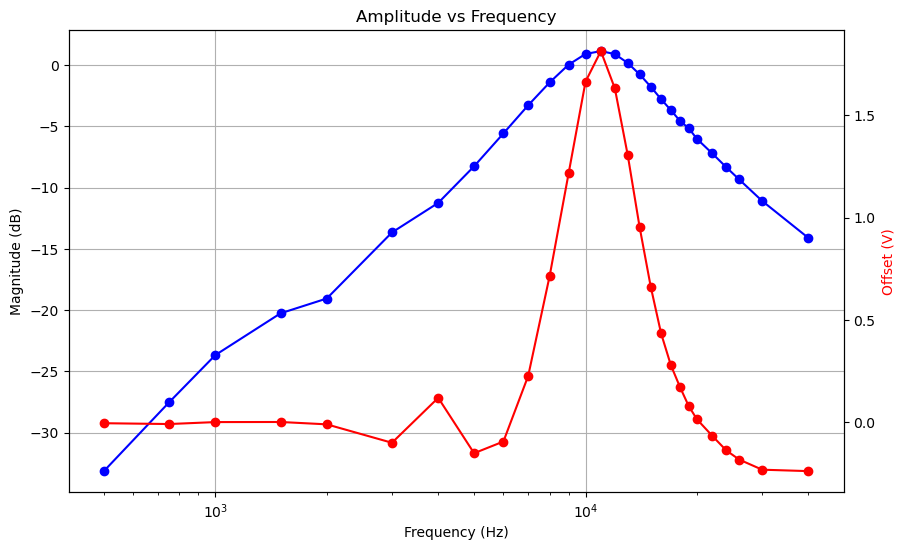

In [11]:
ampl_indB = 20 * np.log10(ampl)
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Amplitude vs Frequency')
ax.plot(freq, ampl_indB, 'o-', color='blue')


ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax2 = ax.twinx()
ax2.plot(freq, offset, 'o-', color='red')
ax2.set_ylabel('Offset (V)', color='red')
ax.grid();

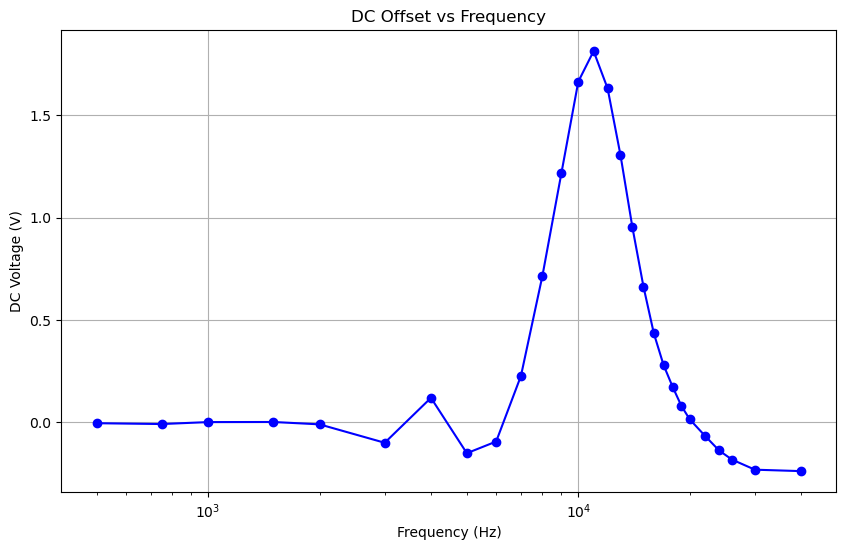

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('DC Offset vs Frequency')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('DC Voltage (V)')
ax.plot(freq, offset, 'o-', color='blue')
ax.set_xscale('log')
ax.grid();